In [85]:
import torch
from matplotlib import pyplot as plt

In [86]:
import torch.nn as nn
import torch.optim as optim

In [87]:
# Distances in miles
distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)
print(distances)
# Delivery times in minutes
times = torch.tensor([[6.96],[12.11],[16.77],[22.21]], dtype=torch.float32)


tensor([[1.],
        [2.],
        [3.],
        [4.]])


In [88]:
model = nn.Sequential(nn.Linear(1,1))

In [89]:
# Loss function and optimizer
loss_function = nn.MSELoss() # Mean Squared Error
optimizer = optim.SGD(model.parameters(), lr=0.01) # Stochastic Gradient Descent

In [90]:
# Training loop
for epoch in range(500):
  optimizer.zero_grad() # Resetting the optimizer
  outputs = model(distances)
  loss = loss_function(outputs, times)
  loss.backward() # Calculate adjustments
  optimizer.step() # Update the model
  if(epoch + 1) % 50 == 0:
    print(f"Epoch: {epoch + 1}, Loss: {loss.item()}")

Epoch: 50, Loss: 0.030239034444093704
Epoch: 100, Loss: 0.028987698256969452
Epoch: 150, Loss: 0.02806270681321621
Epoch: 200, Loss: 0.027377549558877945
Epoch: 250, Loss: 0.02686966210603714
Epoch: 300, Loss: 0.02649342268705368
Epoch: 350, Loss: 0.02621460147202015
Epoch: 400, Loss: 0.02600811794400215
Epoch: 450, Loss: 0.025855056941509247
Epoch: 500, Loss: 0.02574154920876026


In [91]:
# Inference - Testing with new input data
with torch.no_grad():
  test_distance = torch.tensor([[25.0]], dtype=torch.float32)
  predicted_time = model(test_distance)
  print(f"Predicted time for distance {test_distance.item()} miles: {predicted_time.item():.1f} minutes")

Predicted time for distance 25.0 miles: 127.6 minutes


In [92]:
with torch.no_grad():
  predicted_times = model(distances)

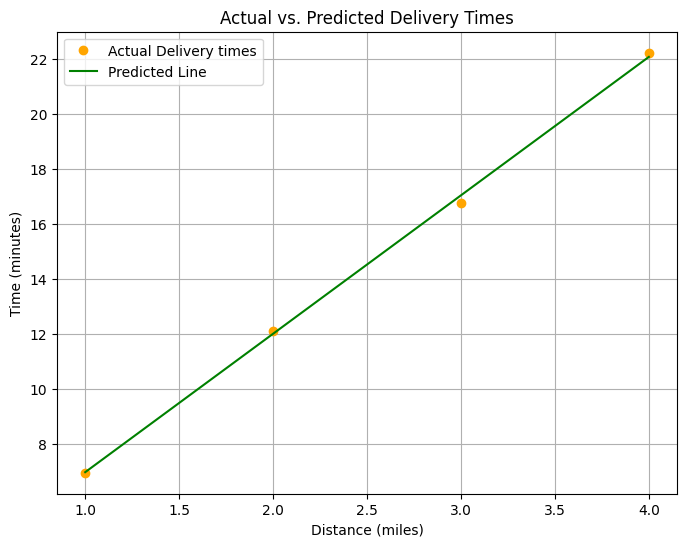

In [93]:
plt.figure(figsize=(8, 6))
plt.plot(distances, times, color='orange', marker='o', linestyle='none', label='Actual Delivery times')
plt.plot(distances, predicted_times, color='green', marker='None', label='Predicted Line')
# Set the title of the plot
plt.title('Actual vs. Predicted Delivery Times')
# Set the x-axis label
plt.xlabel('Distance (miles)')
# Set the y-axis label
plt.ylabel('Time (minutes)')
# Display the legend
plt.legend()
# Add a grid to the plot
plt.grid(True)
# Show the plot
plt.show()

In [94]:
with torch.no_grad():
  test_distance = torch.tensor([[7.0]], dtype=torch.float32)
  predicted_time = model(test_distance)
  print(f"Predicted time for distance {test_distance.item()} miles: {predicted_time.item():.1f} minutes")

Predicted time for distance 7.0 miles: 37.1 minutes


In [95]:
model[0].weight.data

tensor([[5.0261]])

In [101]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

In [102]:
with torch.no_grad():
  new_predicted_times = model(new_distances)

In [104]:
new_loss = loss_function(new_predicted_times, new_times)
print(f"New Loss: {new_loss.item():.2f}")

New Loss: 178.03


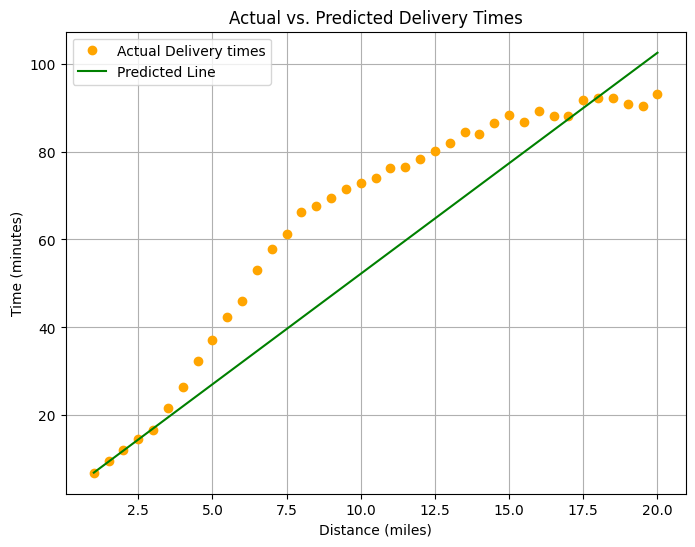

In [106]:
plt.figure(figsize=(8, 6))
plt.plot(new_distances, new_times, color='orange', marker='o', linestyle='none', label='Actual Delivery times')
plt.plot(new_distances, new_predicted_times, color='green', marker='None', label='Predicted Line')
# Set the title of the plot
plt.title('Actual vs. Predicted Delivery Times')
# Set the x-axis label
plt.xlabel('Distance (miles)')
# Set the y-axis label
plt.ylabel('Time (minutes)')
# Display the legend
plt.legend()
# Add a grid to the plot
plt.grid(True)
# Show the plot
plt.show()